In [1]:
import pandas as pd

In [2]:
full_table = pd.read_parquet("../data/processed/fuel_clean.parquet")
full_table.head()

,ServiceStationName,Address,Suburb,Postcode,Brand,FuelCode,PriceUpdatedDate,Price,source_file,state,brand_group,fuel_name
0,Ampol Denham Court,"194 CAMPBELLTOWN RD, DENHAM COURT NSW 2565",DENHAM COURT,2565,Ampol,U91,2026-04-01 00:06:24,239.5,fuelcheck_pricehistory_apr2026.xlsx,NSW,Ampol,Unleaded 91
1,Liberty Albert,"9, Melrose Road, Albert NSW 2873",Albert,2873,Liberty,U91,2026-04-01 00:22:59,274.9,fuelcheck_pricehistory_apr2026.xlsx,NSW,Liberty,Unleaded 91
2,Liberty Bourke,"96-104 ANSON ST, BOURKE NSW 2840",BOURKE,2840,Liberty,U91,2026-04-01 00:23:27,264.9,fuelcheck_pricehistory_apr2026.xlsx,NSW,Liberty,Unleaded 91
3,Liberty Bourke,"96-104 ANSON ST, BOURKE NSW 2840",BOURKE,2840,Liberty,P95,2026-04-01 00:23:27,274.9,fuelcheck_pricehistory_apr2026.xlsx,NSW,Liberty,Premium Unleaded Petrol 95
4,SHELL TAMWORTH TRUCKSTOP (unmanned),"9-13 Gunnedah Road, Tamworth NSW 2340",Tamworth,2340,Shell,DL,2026-04-01 00:23:53,299.9,fuelcheck_pricehistory_apr2026.xlsx,NSW,Shell,Diesel


### Cheapest Day of the Week for Fuel

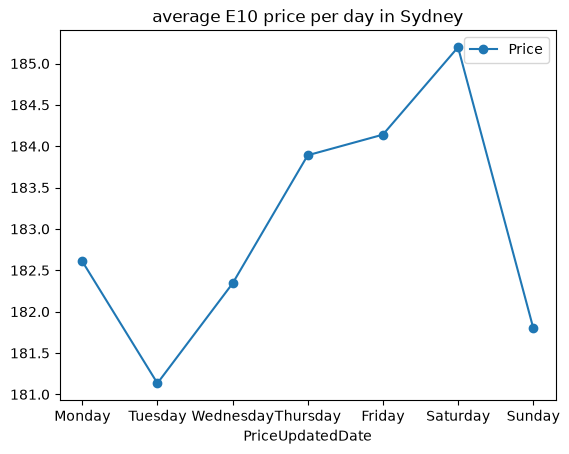

In [3]:
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
full_table["Postcode"] = full_table["Postcode"].astype("int16")

sydney_oil = full_table.loc[(
                            (full_table["Postcode"].between(2000, 2234)) | 
                            (full_table["Postcode"].between(2555, 2574)) | 
                            (full_table["Postcode"].between(2740, 2786))
                           )]

(sydney_oil.loc[sydney_oil["FuelCode"] == "E10"]
    .groupby(sydney_oil["PriceUpdatedDate"].dt.day_name())
    .agg({"Price":"mean"})
    .reindex(days)
).plot(title="average E10 price per day in Sydney",
       marker="o");

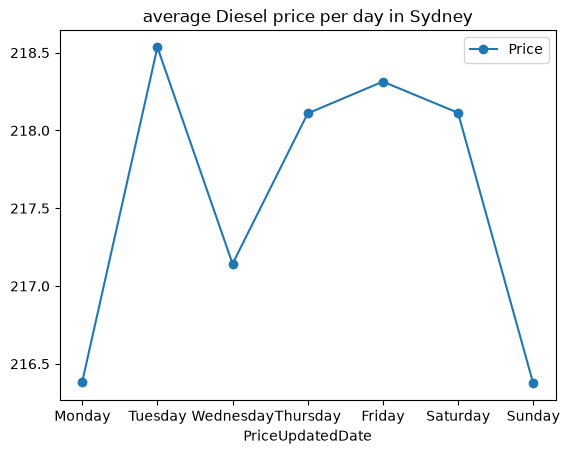

In [ ]:
(sydney_oil.loc[sydney_oil["FuelCode"] == "DL"]
    .groupby(sydney_oil["PriceUpdatedDate"].dt.day_name())
    .agg({"Price":"mean"})
    .reindex(days)
).plot(title="average Diesel price per day in Sydney",
       marker="o");

- The cheapest days for E10 are Tuesday and Sunday and the  most expensive day is Saturday
- The cheapest days for Diesel are Monday and Sunday and the most expensive day is Tuesday
- For vans and trucks, the most economically efficient day for buying fuel is Sunday

### Comparison of Diesel Prices Across Brands

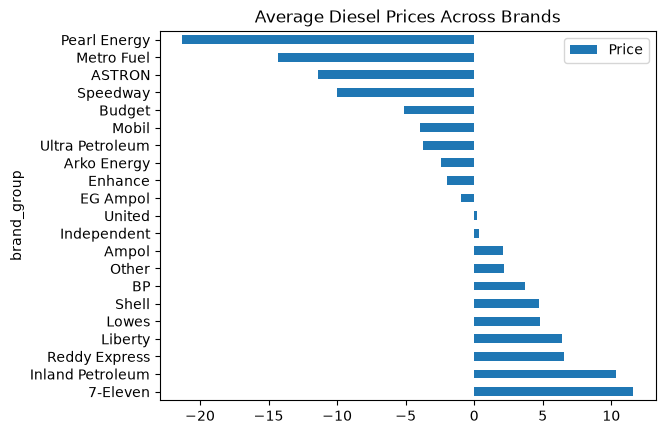

In [5]:
diesel_avg = full_table.loc[((full_table["FuelCode"] == "DL") & (full_table["state"] == "NSW"))]["Price"].mean()

((full_table
    .loc[((full_table["FuelCode"] == "DL") & (full_table["state"] == "NSW"))]
    .groupby("brand_group")
    .agg({"Price": "mean"}) - diesel_avg)
    .sort_values(by="Price", ascending=False)
    .plot.barh(title="Average Diesel Prices Across Brands"));

- Pearl Energy, Metro Fuel, and ASTRON are 3 of the cheapest brands
- 7-Eleven, Inland Petroleum, and Reddy Express are 3 of the most expensive brands

### Sydney vs. regional NSW

In [6]:
NSW_table = full_table.loc[full_table["state"] == "NSW"]
NSW_sorting = {True: "Sydney", False: "Regional"}

In [7]:
NSW_table["region_label"] = ((NSW_table["Postcode"].between(2000, 2234)) | (NSW_table["Postcode"].between(2555, 2574)) | (NSW_table["Postcode"].between(2740, 2786))).map(NSW_sorting)

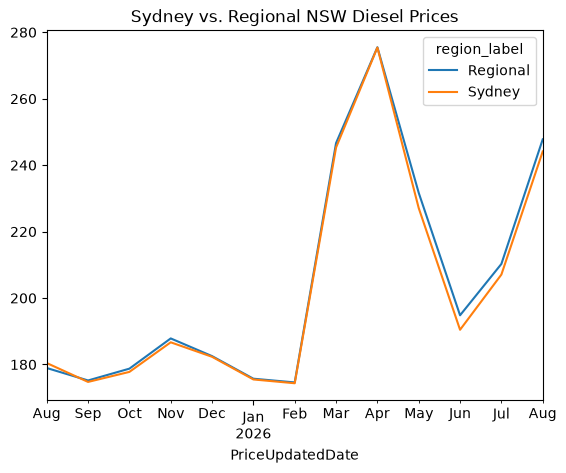

In [12]:
NSW_table.loc[NSW_table["FuelCode"] == "DL"].pivot_table(index=NSW_table["PriceUpdatedDate"].dt.to_period('M'),
                                                         values="Price",
                                                         columns="region_label").plot(title="Sydney vs. Regional NSW Diesel Prices");